# ✈️ Aircraft Digital Twin - Core Flow Demo

Notebook này minh họa luồng hoạt động chính yếu của hệ thống
Bỏ qua các bước thử nghiệm, test model phụ (như Random Forest) và đi thẳng vào **Digital Twin** với **LSTM** và **PPO**.

In [1]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scripts.eval_utils import evaluate_lstm_performance
from scripts.rl_eval import evaluate_rl_agent

from sklearn.metrics import r2_score

import importlib
import scripts.lstm_model
import scripts.eval_utils
# Reload các module để cập nhật code mới nhất từ file .py
importlib.reload(scripts.lstm_model)
importlib.reload(scripts.eval_utils)

# Ensure project root is in path
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

from scripts.data_processor import prepare_data, FEATURES, KEY_SENSORS
from scripts.lstm_model import create_sequences, train_model
from scripts.aircraft_env import AircraftEnv

## 1. Load Dữ Liệu

In [2]:
data_dir = os.path.join(PROJECT_ROOT, 'CMAPSSData') 
train_rolling, test_rolling, true_rul, scaler = prepare_data(data_dir)
print("Dữ liệu đã được nạp thành công!")

Loaded CMAPSS data: 20631 train rows, 13096 test rows, 100 engines
Scaler fitted on 16 features
Dữ liệu đã được nạp thành công!


## 2. Huấn Luyện hoặc Load LSTM Model

In [3]:
# Định nghĩa đường dẫn lưu model
model_path = os.path.join(PROJECT_ROOT, 'models', 'lstm_rul_model.keras')

if os.path.exists(model_path):
    lstm_model = tf.keras.models.load_model(model_path)
    print(f"📦 Đã load LSTM model thành công từ: {model_path}")
else:
    print("🧠 Không tìm thấy model có sẵn. Bắt đầu huấn luyện LSTM mới...")
    # Chuẩn bị sequence cho training
    X_train, y_train = create_sequences(train_rolling, scaler)
    # Train model (epochs thấp để demo chạy nhanh)
    lstm_model, history = train_model(X_train, y_train, epochs=54)
    
    # Lưu model
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    lstm_model.save(model_path)
    print(f"💾 Đã huấn luyện và lưu LSTM model tại: {model_path}")

📦 Đã load LSTM model thành công từ: c:\Users\tung\Downloads\RL\Project\models\lstm_rul_model.keras


## 2.1 Đánh Giá Model LSTM

Chúng ta sẽ đánh giá model trên tập test bằng chỉ số **R2 Score** và vẽ biểu đồ **Loss** trong quá trình huấn luyện.

📊 Calculating metrics on the test set...
✅ R2 Score:  0.8604
✅ RMSE:      15.53 cycles
✅ MAE:       11.28 cycles


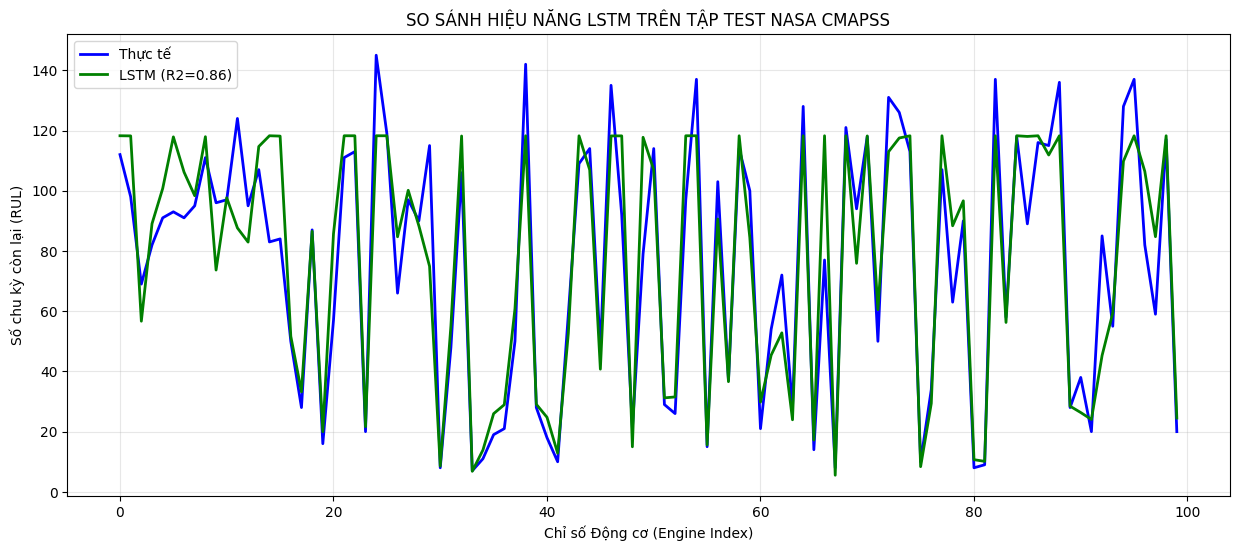

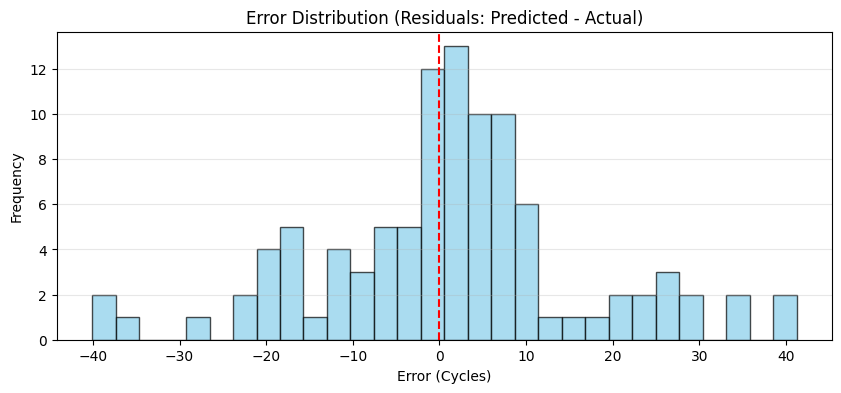

In [4]:
# Tính RMSE, MAE và vẽ biểu đồ phân phối lỗi
y_true, y_pred = evaluate_lstm_performance(lstm_model, test_rolling, true_rul, scaler)

## 3. Khởi Tạo Môi Trường Mô Phỏng (RL Environment)

In [5]:
env = AircraftEnv(
    fleet_data=train_rolling,
    model=lstm_model,
    scaler=scaler,
    sensor_list=KEY_SENSORS,
    features_list=FEATURES
)

print("✈️ Khởi tạo môi trường Digital Twin hoàn tất.")

✈️ Khởi tạo môi trường Digital Twin hoàn tất.


## 4. Huấn luyện Agent (PPO - Reinforcement Learning)

In [ ]:
import os
import mlflow
import importlib
from datetime import datetime
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.env_util import make_vec_env  
from stable_baselines3.common.callbacks import EvalCallback, CallbackList

# Reload custom scripts to pick up changes
import scripts.rl_callbacks
importlib.reload(scripts.rl_callbacks)
from scripts.rl_callbacks import (
    SaveVecNormalizeCallback, 
    MLflowLoggingCallback, 
    SyncVecNormalizeCallback
)

# --- Configuration ---
# 👉 Change this name for each training run to keep them organized!
RUN_NAME = None  # Example: "experiment_v1"

# --- MLFlow Configuration ---
mlflow.set_tracking_uri("http://localhost:5000") 
mlflow.set_experiment("Aircraft_Predictive_Maintenance_v1")

# Auto-generate run name if not provided
if RUN_NAME is None:
    RUN_NAME = f"PPO_Run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
print(f"🏷️ Training run name: {RUN_NAME}")

# Paths for model and normalization stats
repo_ppo_path = os.path.join(PROJECT_ROOT, 'models', f'ppo_aircraft_{RUN_NAME}')
stats_path = os.path.join(PROJECT_ROOT, 'models', f'ppo_aircraft_{RUN_NAME}_vec_normalize.pkl')
best_model_dir = os.path.join(PROJECT_ROOT, 'models', f'best_ppo_{RUN_NAME}')

os.makedirs(best_model_dir, exist_ok=True)

def make_env():
    return AircraftEnv(
        fleet_data=train_rolling,
        model=model_path,
        scaler=scaler,
        sensor_list=KEY_SENSORS,
        features_list=FEATURES
    )

# --- Check for existing model ---
if os.path.exists(repo_ppo_path + ".zip") and os.path.exists(stats_path):
    print(f"📦 Loading PPO agent and normalization stats from: {repo_ppo_path}")
    train_env = make_vec_env(make_env, n_envs=1)
    train_env = VecNormalize.load(stats_path, train_env)
    train_env.training = False
    train_env.norm_reward = False
    ppo_model = PPO.load(repo_ppo_path, env=train_env)
else:
    print(f"🚀 Training PPO Agent (500k steps) with EvalCallback and MLflow...")
    
    with mlflow.start_run(run_name=RUN_NAME):
        # 1. Setup Training Env
        n_envs = 4
        train_env = make_vec_env(make_env, n_envs=n_envs, vec_env_cls=SubprocVecEnv)
        train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.)
        
        # 2. Setup Eval Env (Stats will be synced from train_env)
        eval_env = make_vec_env(make_env, n_envs=1)
        eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)
        
        # 3. Initialize PPO
        ppo_model = PPO(
            "MlpPolicy", 
            train_env, 
            verbose=1, 
            learning_rate=3e-4,
            tensorboard_log=os.path.join(PROJECT_ROOT, 'logs', 'ppo_demo')
        )
        
        # 4. Log Hyperparameters to MLflow
        params = {
            "total_timesteps": 500000,
            "learning_rate": 3e-4,
            "n_envs": n_envs,
            "run_name": RUN_NAME,
            "gamma": 0.99
        }
        mlflow.log_params(params)
        
        # 5. Set up Callback Chain
        # IMPORTANT: Sync stats TO eval_env before every evaluation
        sync_cb = SyncVecNormalizeCallback(eval_env=eval_env, verbose=1)
        save_vec_stats_cb = SaveVecNormalizeCallback(save_path=best_model_dir, verbose=1)
        
        eval_callback = EvalCallback(
            eval_env, 
            best_model_save_path=best_model_dir,
            log_path=os.path.join(PROJECT_ROOT, 'logs', 'eval_results'), 
            eval_freq=5000, 
            deterministic=True, 
            callback_on_new_best=save_vec_stats_cb,
            callback_after_eval=None # Custom logic could go here
        )
        
        mlflow_cb = MLflowLoggingCallback(verbose=1)
        
        # Combine everything: Sync -> Eval (which triggers Save) -> MLflow
        callback_list = CallbackList([sync_cb, eval_callback, mlflow_cb])
        
        # 6. Start Training
        ppo_model.learn(total_timesteps=params["total_timesteps"], callback=callback_list)
        
        # 7. Final Saving & Artifact Logging
        ppo_model.save(repo_ppo_path)
        train_env.save(stats_path)
        
        # Log results to MLflow artifacts
        mlflow.log_artifact(repo_ppo_path + ".zip", artifact_path="final_model")
        mlflow.log_artifact(stats_path, artifact_path="final_model")
        
        best_zip = os.path.join(best_model_dir, "best_model.zip")
        best_stats = os.path.join(best_model_dir, "vec_normalize.pkl")
        if os.path.exists(best_zip):
            mlflow.log_artifact(best_zip, artifact_path="best_model")
        if os.path.exists(best_stats):
            mlflow.log_artifact(best_stats, artifact_path="best_model")
            
        print(f"💾 Done! Model and stats uploaded to MLflow.")

print("✅ PPO System Ready!")


2026/04/29 23:23:49 INFO mlflow.tracking.fluent: Experiment with name 'Aircraft_Predictive_Maintenance_v1' does not exist. Creating a new experiment.


🏷️ Training run name: PPO_Run_20260429_232349
🚀 Training PPO Agent (500k steps) with EvalCallback and MLflow...
Using cpu device
Logging to c:\Users\tung\Downloads\RL\Project\logs\ppo_demo\PPO_14
🚀 MLflowOutputFormat registered to SB3 Logger.


## 5. Chạy Một Chuyến Bay (Demo Episode)

In [ ]:
obs, info = env.reset()
print("=" * 60)
print(f"🔹 Hành trình bắt đầu!")
print(f"   Động cơ ID: {env.twin.engine_id}")
print(f"   Tổng quãng đường: {env.TOTAL_DISTANCE} | Nhiên liệu đầu vào: {env.twin.fuel}")
print("=" * 60)

# --- PASTE THIS INTO YOUR DEMO EPISODE CELL ---
done = False
steps = 0
total_reward = 0

# Mapping action integers to names
action_names = {0: "CRUISE", 1: "DESCEND", 2: "CLIMB"}

while not done and steps < 500:
    if ppo_model is not None:
        # PPO Agent decides between CRUISE, DESCEND, or CLIMB
        action, _states = ppo_model.predict(obs, deterministic=True)
    else:
        # Heuristic Fallback:
        # If RUL > 40: CRUISE (0)
        # If RUL <= 40: DESCEND (1) to find a landing spot
        current_rul = env.twin.current_rul if env.twin.current_rul is not None else 150
        action = 0 if current_rul > 40 else 1
    
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward
    steps += 1
    
    # Print status every 20 steps or on special events
    if steps % 10 == 0 or done or 'event' in info:
        act_name = action_names.get(int(action), "UNKNOWN")
        rul_val = obs[3]
        fuel_val = obs[2]
        dist_next = obs[4] # Distance to the nearest airport ahead
        dist_dest = obs[5] # Distance to final destination
        
        print(f"Chu kỳ {steps:>4} | Hành động: {act_name:>7} | RUL: {rul_val:>6.1f} | Xăng: {fuel_val:>5.1f} | Sân bay gần nhất: {dist_next:>7.0f} | Đích: {dist_dest:>7.0f}")

print("=" * 70)
print(f"🛬 Kết thúc chuyến bay: {info.get('event', 'TIMEOUT')}")
print(f"   Tổng bước bay: {steps} | Tổng phần thưởng: {total_reward}")


🔹 Hành trình bắt đầu!
   Động cơ ID: 71
   Tổng quãng đường: 5000.0 | Nhiên liệu đầu vào: 200.0
Chu kỳ   10 | Hành động:  CRUISE | RUL:  118.3 | Xăng: 195.0 | Sân bay gần nhất:    1000 | Đích:    4750
Chu kỳ   20 | Hành động:  CRUISE | RUL:  118.2 | Xăng: 190.0 | Sân bay gần nhất:     750 | Đích:    4500
Chu kỳ   30 | Hành động:  CRUISE | RUL:  118.3 | Xăng: 185.0 | Sân bay gần nhất:     500 | Đích:    4250
Chu kỳ   40 | Hành động:  CRUISE | RUL:  118.3 | Xăng: 180.0 | Sân bay gần nhất:     250 | Đích:    4000
Chu kỳ   50 | Hành động:  CRUISE | RUL:  118.3 | Xăng: 175.0 | Sân bay gần nhất:    1250 | Đích:    3750
Chu kỳ   60 | Hành động:  CRUISE | RUL:  118.1 | Xăng: 170.0 | Sân bay gần nhất:    1000 | Đích:    3500


KeyboardInterrupt: 

In [ ]:
# Chạy thử 20 episodes trên tập Test để xem tỷ lệ thành công
eval_results = evaluate_rl_agent(ppo_model, test_rolling, lstm_model, scaler, num_episodes=20)